# Регрессия для IC50

## Цель работы
Построить и сравнить несколько моделей машинного обучения для предсказания значения IC50, mM на основе молекулярных дескрипторов.

## План
1. Загрузить данные.
2. Подготовить признаки.
3. Разделить выборку на train/test.
4. Обучить несколько моделей.
5. Сравнить модели по метрикам.
6. Подобрать гиперпараметры для лучшей модели.
7. Сделать вывод.

## За основу берем материал из лекций следующих модулей:
- **Модуль 2. Регрессионные задачи** - постановка задачи регрессии, метрики MAE, MSE, RMSE, R², разбиение выборки.
- **Модуль 5. Метод опорных векторов** - применение SVR для регрессии.
- **Модуль 6. Оптимизация и настройка моделей** - Pipeline, GridSearchCV, настройка гиперпараметров.

# 1. Импорт библиотек

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

# 2. Загрузка данных

In [ ]:
df = pd.read_excel("Данные_для_курсовои_Классическое_МО.xlsx")

print("Размер таблицы:", df.shape)
display(df.head())

Размер таблицы: (1001, 214)


,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,340.300,384.350449,158,0,0.038844,-0.293526,0.293526,0.038844,0.642857,1.035714,1.321429,14.822266,9.700470,2.600532,-2.343082,2.644698,-2.322229,5.944519,0.193481,3.150503,1.164038,611.920301,20.208896,19.534409,19.534409,13.127794,12.204226,12.204226,12.058078,12.058078,10.695991,10.695991,7.340247,7.340247,-0.66,2.187750e+06,20.606247,6.947534,2.868737,173.630124,0.000000,0.0,0.0,0.0,0.0,0.0,9.984809,0.0,0.0,0.0,54.384066,74.032366,35.342864,0.000000,0.000000,11.423370,0.0,0.000000,43.480583,105.750639,13.089513,0.00000,0,0.0,0.000000,0.000000,0.0,0.0,24.512883,0.000000,33.495774,105.750639,9.984809,0.0,0.0,0,24.72,0.0,0.0,0.0,0.000000,21.659962,24.925325,64.208216,11.42337,0.0,41.542423,9.984809,0.00000,0.0,10.188192,0.000000,4.807589,1.764908,0.000000,13.258223,16.981087,0.000000,0.923077,28,0,2,4,0,4,0,0,0,2,0,2,7,4,0,4,4,7.1212,121.5300,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,340.300,388.381750,162,0,0.012887,-0.313407,0.313407,0.012887,0.607143,1.000000,1.285714,14.975110,9.689226,2.614066,-2.394690,2.658342,-2.444817,5.134527,0.120322,3.150503,1.080362,516.780124,20.208896,19.794682,19.794682,13.127794,12.595754,12.595754,12.648545,12.

#3. Первичный анализ данных

In [ ]:
print("Список столбцов:")
display(df.columns.tolist())

print("Типы данных:")
display(df.dtypes.value_counts())

print("Пропуски по столбцам:")
display(df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False).head(20))

Список столбцов:


['Unnamed: 0',
 'IC50, mM',
 'CC50, mM',
 'SI',
 'MaxAbsEStateIndex',
 'MaxEStateIndex',
 'MinAbsEStateIndex',
 'MinEStateIndex',
 'qed',
 'SPS',
 'MolWt',
 'HeavyAtomMolWt',
 'ExactMolWt',
 'NumValenceElectrons',
 'NumRadicalElectrons',
 'MaxPartialCharge',
 'MinPartialCharge',
 'MaxAbsPartialCharge',
 'MinAbsPartialCharge',
 'FpDensityMorgan1',
 'FpDensityMorgan2',
 'FpDensityMorgan3',
 'BCUT2D_MWHI',
 'BCUT2D_MWLOW',
 'BCUT2D_CHGHI',
 'BCUT2D_CHGLO',
 'BCUT2D_LOGPHI',
 'BCUT2D_LOGPLOW',
 'BCUT2D_MRHI',
 'BCUT2D_MRLOW',
 'AvgIpc',
 'BalabanJ',
 'BertzCT',
 'Chi0',
 'Chi0n',
 'Chi0v',
 'Chi1',
 'Chi1n',
 'Chi1v',
 'Chi2n',
 'Chi2v',
 'Chi3n',
 'Chi3v',
 'Chi4n',
 'Chi4v',
 'HallKierAlpha',
 'Ipc',
 'Kappa1',
 'Kappa2',
 'Kappa3',
 'LabuteASA',
 'PEOE_VSA1',
 'PEOE_VSA10',
 'PEOE_VSA11',
 'PEOE_VSA12',
 'PEOE_VSA13',
 'PEOE_VSA14',
 'PEOE_VSA2',
 'PEOE_VSA3',
 'PEOE_VSA4',
 'PEOE_VSA5',
 'PEOE_VSA6',
 'PEOE_VSA7',
 'PEOE_VSA8',
 'PEOE_VSA9',
 'SMR_VSA1',
 'SMR_VSA10',
 'SMR_VSA2',
 'SM

Типы данных:


,count
int64,107
float64,107


Пропуски по столбцам:


,0
MaxPartialCharge,3
MinPartialCharge,3
MaxAbsPartialCharge,3
MinAbsPartialCharge,3
BCUT2D_MWHI,3
BCUT2D_MWLOW,3
BCUT2D_CHGHI,3
BCUT2D_CHGLO,3
BCUT2D_LOGPHI,3
BCUT2D_LOGPLOW,3


## Первичный анализ данных

На этом этапе проводится базовый анализ структуры датасета:
- размер таблицы;
- названия столбцов;
- типы данных;
- наличие пропусков.

Подход основан на **модуле 2**, где подчёркивалась важность подготовки данных перед обучением модели.

#4. Подготовка признаков

In [ ]:
# удаляем служебный столбец
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

target = "IC50, mM"

# удаляем строки без целевой переменной
df = df.dropna(subset=[target]).copy()

# признаки и целевая переменная
X = df.drop(columns=["IC50, mM", "CC50, mM", "SI"], errors="ignore")
y = df[target]

print("Размер X:", X.shape)
print("Размер y:", y.shape)

display(X.head())

Размер X: (1001, 210)
Размер y: (1001,)


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,340.300,384.350449,158,0,0.038844,-0.293526,0.293526,0.038844,0.642857,1.035714,1.321429,14.822266,9.700470,2.600532,-2.343082,2.644698,-2.322229,5.944519,0.193481,3.150503,1.164038,611.920301,20.208896,19.534409,19.534409,13.127794,12.204226,12.204226,12.058078,12.058078,10.695991,10.695991,7.340247,7.340247,-0.66,2.187750e+06,20.606247,6.947534,2.868737,173.630124,0.000000,0.0,0.0,0.0,0.0,0.0,9.984809,0.0,0.0,0.0,54.384066,74.032366,35.342864,0.000000,0.000000,11.423370,0.0,0.000000,43.480583,105.750639,13.089513,0.00000,0,0.0,0.000000,0.000000,0.0,0.0,24.512883,0.000000,33.495774,105.750639,9.984809,0.0,0.0,0,24.72,0.0,0.0,0.0,0.000000,21.659962,24.925325,64.208216,11.42337,0.0,41.542423,9.984809,0.00000,0.0,10.188192,0.000000,4.807589,1.764908,0.000000,13.258223,16.981087,0.000000,0.923077,28,0,2,4,0,4,0,0,0,2,0,2,7,4,0,4,4,7.1212,121.5300,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0
1,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,340.300,388.381750,162,0,0.012887,-0.313407,0.313407,0.012887,0.607143,1.000000,1.285714,14.975110,9.689226,2.614066,-2.394690,2.658342,-2.444817,5.134527,0.120322,3.150503,1.080362,516.780124,20.208896,19.794682,19.794682,13.127794,12.595754,12.595754,12.648545,12.648545,11.473090,11.473090,8.180905,8.180905,-0.08,2.187750e+06,21.163454,7.257648,3.027177,174.9

#5. Проверка типов признаков

In [ ]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Числовых признаков:", len(numeric_features))
print("Категориальных признаков:", len(categorical_features))

Числовых признаков: 210
Категориальных признаков: 0


## Подготовка признаков

Для задачи регрессии IC50 в качестве признаков используются молекулярные дескрипторы.  
Из признаков удалены:
- IC50, mM - целевая переменная текущей задачи;
- CC50, mM и SI - другие целевые признаки, которые нельзя использовать как входы, чтобы не допустить утечки информации.

Подход основан на **модуле 2**.

#6.Train/Test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800, 210)
X_test: (201, 210)
y_train: (800,)
y_test: (201,)


#7.Предобработка

In [ ]:
preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

Поскольку в датасете практически все признаки числовые, используем:
- заполнение пропусков медианой;
- стандартизацию признаков.

Это основано на:
- **модуле 2** - работа с пропусками и масштабирование;
- **модуле 6** - организация шагов предобработки через Pipeline.

#8. Список моделей

In [ ]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42),
    "RandomForestRegressor": RandomForestRegressor(random_state=42),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=42),
    "SVR": SVR()
}

## Почему были выбраны именно эти модели:

В работе использовались как простые линейные модели, так и более сложные нелинейные алгоритмы.  
Это сделано для того, чтобы сравнить, насколько сложная модель действительно даёт прирост качества по сравнению с базовыми методами.

- LinearRegression, Ridge, Lasso - базовые регрессионные методы из **модуля 2**;
- SVR - более гибкий метод из **модуля 5**;
- RandomForestRegressor и GradientBoostingRegressor - нелинейные ансамблевые методы, позволяющие учитывать сложные зависимости между признаками.

Перед обучением можно ожидать, что ансамблевые модели и метод опорных векторов покажут более высокое качество, чем простые линейные методы, так как зависимости между дескрипторами и целевой переменной, вероятно, являются нелинейными.

#9. Обучение и сравнение моделей

In [ ]:
results = []

for model_name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results).sort_values(by="RMSE")
display(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.405e+04, tolerance: 9.332e+03
  model = cd_fast.enet_coordinate_descent(


,Model,MAE,MSE,RMSE,R2
4,GradientBoostingRegressor,231.529814,192959.148333,439.271156,0.421515
3,RandomForestRegressor,233.788285,193144.807607,439.482432,0.420958
2,Lasso,256.165767,211879.871746,460.304108,0.364791
1,Ridge,263.317276,216615.058030,465.419228,0.350595
0,LinearRegression,287.954246,256347.251599,506.307467,0.231479
5,SVR,276.586888,393458.223805,627.262484,-0.179575


#10. Визуализация сравнения моделей

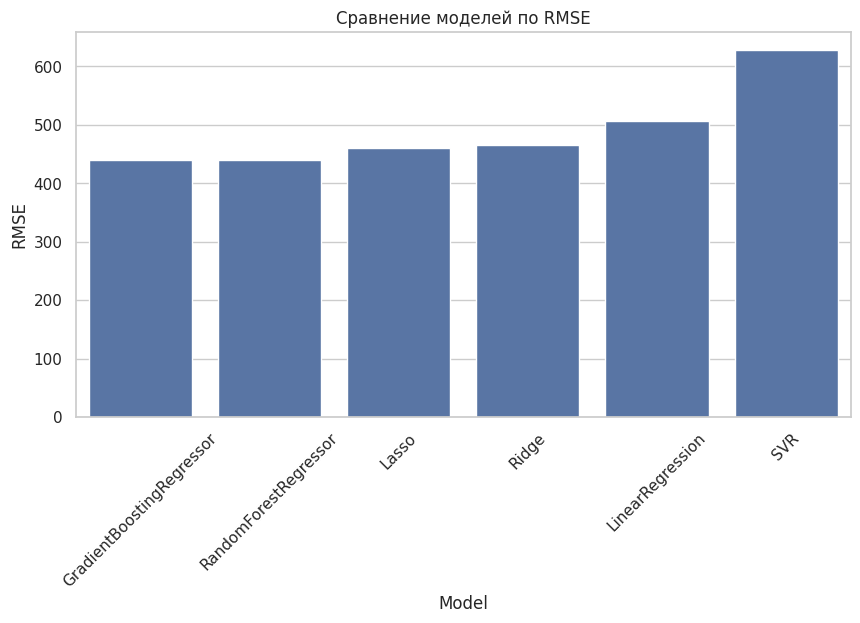

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="RMSE")
plt.xticks(rotation=45)
plt.title("Сравнение моделей по RMSE")
plt.show()

## Сравнение моделей

В работе сравниваются несколько моделей:
- LinearRegression, Ridge, Lasso - основаны на **модуле 2**;
- SVR - основан на **модуле 5**;
- RandomForestRegressor и GradientBoostingRegressor добавлены как более гибкие нелинейные модели для исследовательского сравнения.

Для оценки используются метрики:
- MAE
- MSE
- RMSE
- R²

Использование этих метрик основано на **модуле 2**.

#11. Выбор лучшей модели

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
print("Лучшая модель по RMSE:", best_model_name)

Лучшая модель по RMSE: GradientBoostingRegressor


#12. Подбор гиперпараметров

In [ ]:
if best_model_name == "Ridge":
    param_grid = {
        "model__alpha": [0.1, 1.0, 10.0]
    }
    best_model = Ridge(random_state=42)

elif best_model_name == "Lasso":
    param_grid = {
        "model__alpha": [0.001, 0.01, 0.1]
    }
    best_model = Lasso(random_state=42, max_iter=5000)

elif best_model_name == "RandomForestRegressor":
    param_grid = {
        "model__n_estimators": [100],
        "model__max_depth": [5, 10],
        "model__min_samples_split": [2, 5]
    }
    best_model = RandomForestRegressor(random_state=42, n_jobs=-1)

elif best_model_name == "GradientBoostingRegressor":
    param_grid = {
        "model__n_estimators": [100],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [2, 3]
    }
    best_model = GradientBoostingRegressor(random_state=42)

elif best_model_name == "SVR":
    param_grid = {
        "model__kernel": ["rbf"],
        "model__C": [1, 10],
        "model__epsilon": [0.1, 0.5],
        "model__gamma": ["scale"]
    }
    best_model = SVR()

else:
    param_grid = {}
    best_model = LinearRegression()

best_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_model)
])

if param_grid:
    grid_search = GridSearchCV(
        estimator=best_pipe,
        param_grid=param_grid,
        cv=3,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    print("Лучшие параметры:")
    print(grid_search.best_params_)

    tuned_model = grid_search.best_estimator_
else:
    best_pipe.fit(X_train, y_train)
    tuned_model = best_pipe

Лучшие параметры:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}


#13. Оценка лучшей модели после настройки

In [ ]:
y_pred_tuned = tuned_model.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Метрики лучшей модели после настройки:")
print("MAE:", mae_tuned)
print("MSE:", mse_tuned)
print("RMSE:", rmse_tuned)
print("R2:", r2_tuned)

Метрики лучшей модели после настройки:
MAE: 236.33199446325054
MSE: 194316.3911167849
RMSE: 440.8133291051722
R2: 0.41744560489209126


#14. График истинных и предсказанных значений

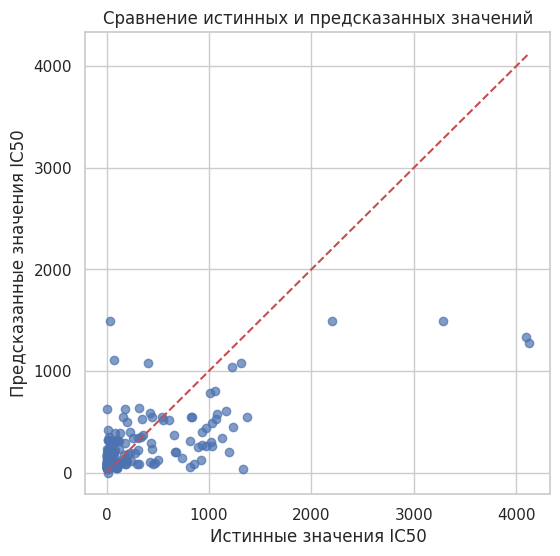

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_tuned, alpha=0.7)
plt.xlabel("Истинные значения IC50")
plt.ylabel("Предсказанные значения IC50")
plt.title("Сравнение истинных и предсказанных значений")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.show()

## Подбор гиперпараметров

Подбор гиперпараметров выполнен с помощью GridSearchCV.

Этот блок основан на:
- **модуле 6** - GridSearchCV, настройка гиперпараметров;
- **модуле 5** - если лучшей моделью оказывается SVR, то используются параметры C, epsilon, kernel, gamma.

#15. Анализ важности признаков

Для лучшей модели дополнительно проводится анализ признаков, чтобы понять, какие дескрипторы сильнее влияют на предсказание IC50.

Этот этап основан на:
- **модуле 4** - ансамблевые модели;
- **модуле 6** - интерпретируемость модели и отбор признаков.

,Feature,Importance
36,Chi2v,0.078615
35,Chi2n,0.066832
25,BCUT2D_MRLOW,0.064083
33,Chi1n,0.061285
99,VSA_EState4,0.058471
88,EState_VSA3,0.039239
13,MaxAbsPartialCharge,0.032775
17,FpDensityMorgan3,0.031151
103,VSA_EState8,0.031061
44,Kappa2,0.027656


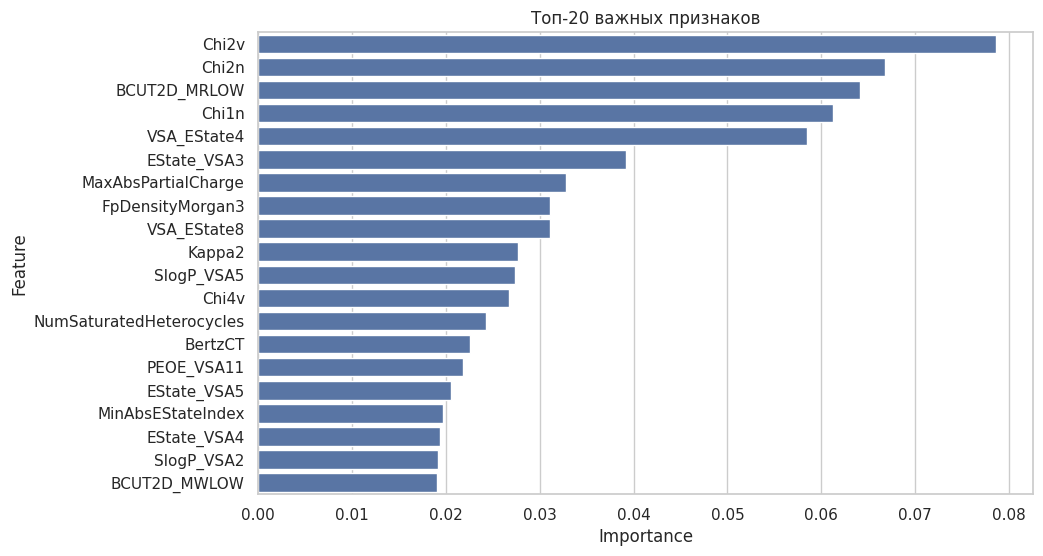

In [ ]:
if best_model_name in ["RandomForestRegressor", "GradientBoostingRegressor"]:
    model_step = tuned_model.named_steps["model"]

    feature_importance_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": model_step.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    display(feature_importance_df.head(20))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance_df.head(20), x="Importance", y="Feature")
    plt.title("Топ-20 важных признаков")
    plt.show()

elif best_model_name in ["LinearRegression", "Ridge", "Lasso"]:
    model_step = tuned_model.named_steps["model"]

    coef_df = pd.DataFrame({
        "Feature": X.columns,
        "Coefficient": model_step.coef_
    })

    coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()
    coef_df = coef_df.sort_values(by="AbsCoefficient", ascending=False)

    display(coef_df.head(20))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=coef_df.head(20), x="AbsCoefficient", y="Feature")
    plt.title("Топ-20 признаков по модулю коэффициента")
    plt.show()

# Итоговый вывод

В задаче регрессии для предсказания IC50, mM были обучены и сравнены несколько моделей машинного обучения.  

Наилучший результат на этапе первичного сравнения показала модель GradientBoostingRegressor.

Для неё был выполнен подбор гиперпараметров с помощью GridSearchCV.  
Лучшая комбинация параметров оказалась следующей:

- learning_rate = 0.05
- max_depth = 3
- n_estimators = 100

После настройки гиперпараметров модель показала следующие результаты на тестовой выборке:

- MAE = 236.33
- MSE = 194316.39
- RMSE = 440.81
- R² = 0.4174

Сравнение с исходным вариантом GradientBoostingRegressor показало, что настройка гиперпараметров не привела к улучшению качества на тестовой выборке: значение RMSE оказалось немного выше, а R² немного ниже.  
Следовательно, в данной задаче базовая версия модели GradientBoostingRegressor уже обеспечивала близкое к оптимальному качество.

Таким образом, в данной задаче наиболее эффективной оказалась бустинговая модель, которая показала лучший результат по сравнению с линейными моделями и другими протестированными алгоритмами.


# Рекомендации по улучшению модели

Для дальнейшего повышения качества модели можно рассмотреть следующие шаги:

1. **Провести более тщательный отбор признаков**  
   Часть молекулярных дескрипторов может быть слабо связана с целевой переменной или дублировать друг друга.  
   Это соответствует идеям **модуля 6**, где рассматривались feature selection и интерпретируемость модели.

2. **Проверить влияние выбросов**  
   Для IC50 возможны выбросы, которые увеличивают значение MSE и RMSE.  
   Можно дополнительно проверить устойчивость модели после удаления или ограничения экстремальных значений.

3. **Попробовать логарифмирование целевой переменной**  
   Если распределение IC50 асимметрично, логарифмическое преобразование может сделать задачу более удобной для модели.

4. **Провести более широкий подбор гиперпараметров**  
   В текущей работе использовалась сокращённая сетка параметров, чтобы уменьшить время вычислений.  
   При наличии большего времени можно рассмотреть более широкий диапазон параметров.

5. **Сравнить качество после отбора признаков и PCA**  
   Это может уменьшить шум и улучшить устойчивость модели.